device = cpu
Размер датасета: 4320 записей
Диапазон дат: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Пропуски: 0

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


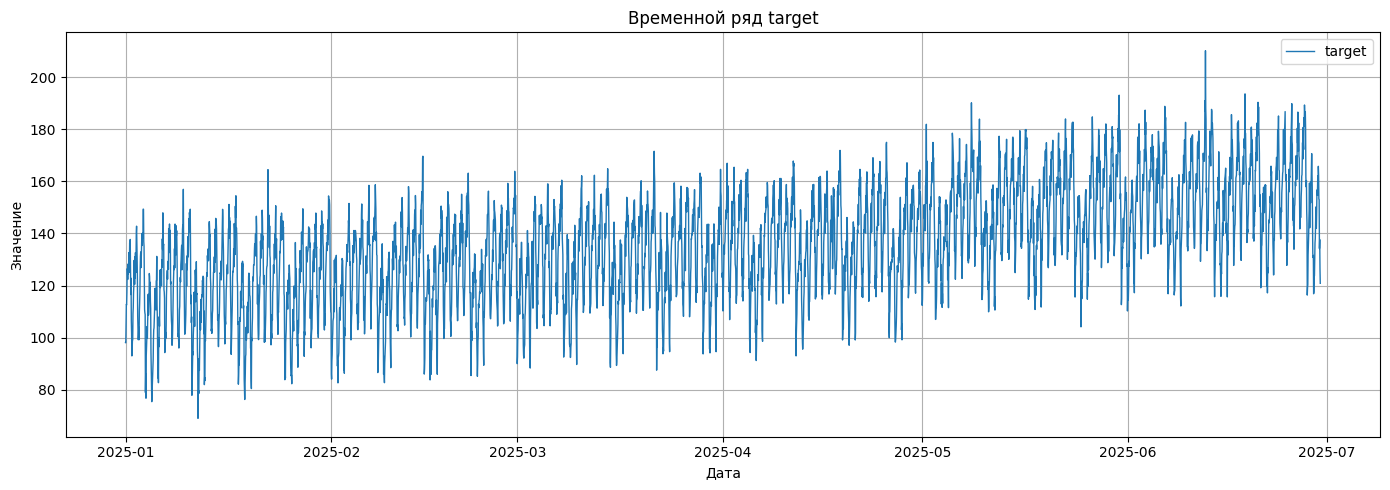


Комментарий к данным:
- Ряд имеет суточную частоту (24 наблюдения в день)
- Наблюдается дневная сезонность (дневные пики)
- Есть недельная сезонность
- Присутствуют выбросы
- Данные стабильны, тренд слабо выражен
train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


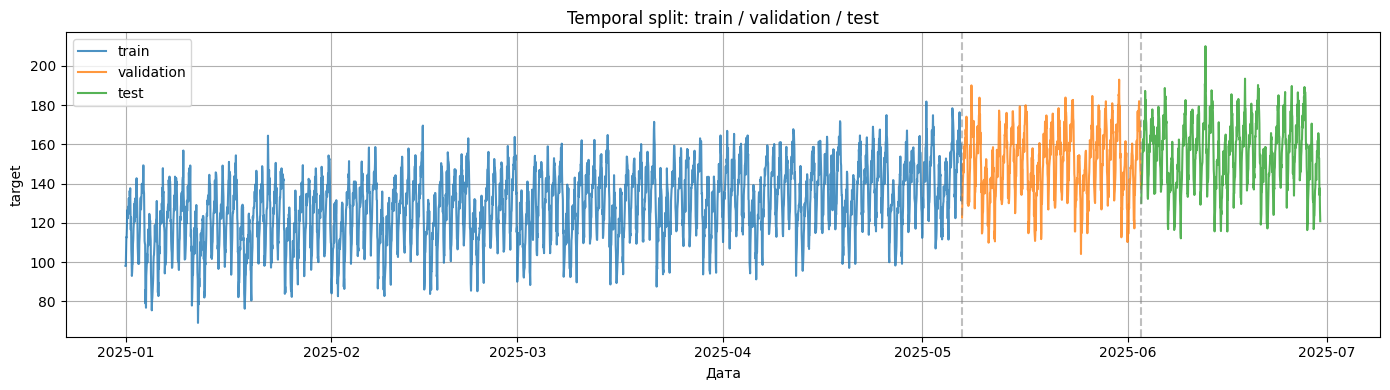


Почему random split некорректен?
При random split данные перемешиваются, и модель может 'подглядывать' в будущее.
В реальном прогнозировании мы предсказываем будущее на основе прошлого.
Temporal split сохраняет хронологический порядок, что соответствует реальной задаче.
После построения признаков: 4306 записей

Проверка созданных признаков:
Наличие lag_1: True
Наличие lag_7: True
Наличие lag_14: True
X_train: (3014, 14), y_train: (3014,)
X_val:   (646, 14), y_val:   (646,)
X_test:  (646, 14), y_test:  (646,)

=== B1: naive-last ===
Validation: MAE=6.4434, RMSE=8.2035, MAPE=4.3946%
Test: MAE=6.3380, RMSE=8.0599, MAPE=4.1435%

=== B2: moving-average ===
Validation: MAE=12.7237, RMSE=15.2363, MAPE=8.8288%
Test: MAE=12.7252, RMSE=15.2262, MAPE=8.5344%

=== B3: ridge-lag-features ===
Validation: MAE=5.5305, RMSE=6.9634, MAPE=3.7012%
Test: MAE=4.8850, RMSE=6.2987, MAPE=3.1766%


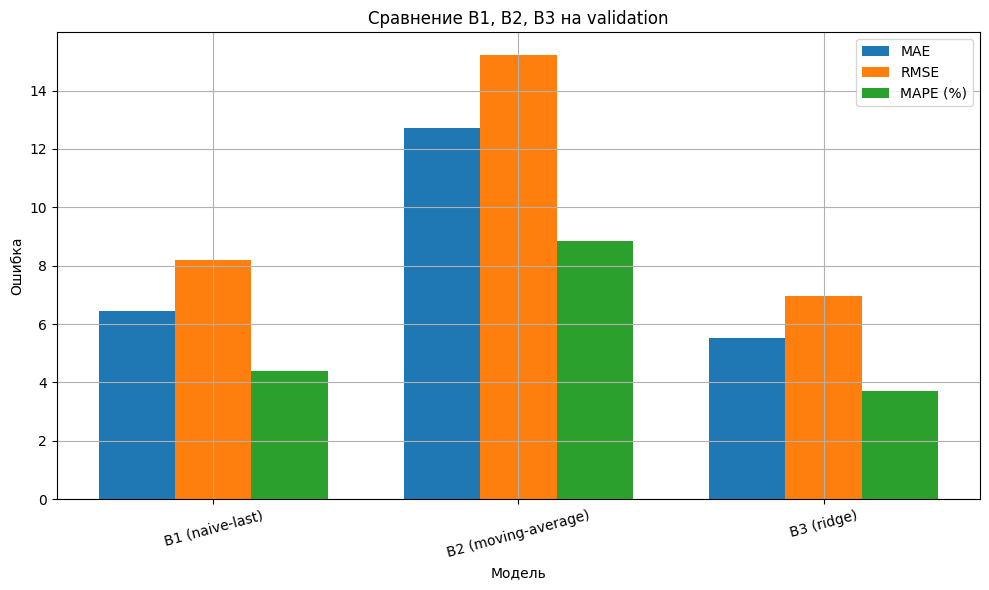

Train samples: 2990
Val samples: 622
Test samples: 622
Model parameters: 37889

=== R1: GRU обучение ===
Epoch 10/50 | train_loss: 0.1067 | val_loss: 0.1791 | val_MAE: 6.0960
Epoch 20/50 | train_loss: 0.1013 | val_loss: 0.1518 | val_MAE: 5.5709
Epoch 30/50 | train_loss: 0.0964 | val_loss: 0.1318 | val_MAE: 5.1051
Epoch 40/50 | train_loss: 0.0938 | val_loss: 0.1330 | val_MAE: 5.1170
Epoch 50/50 | train_loss: 0.0928 | val_loss: 0.1333 | val_MAE: 5.1898

Обучение завершено. Лучшая val_MAE: 5.0084


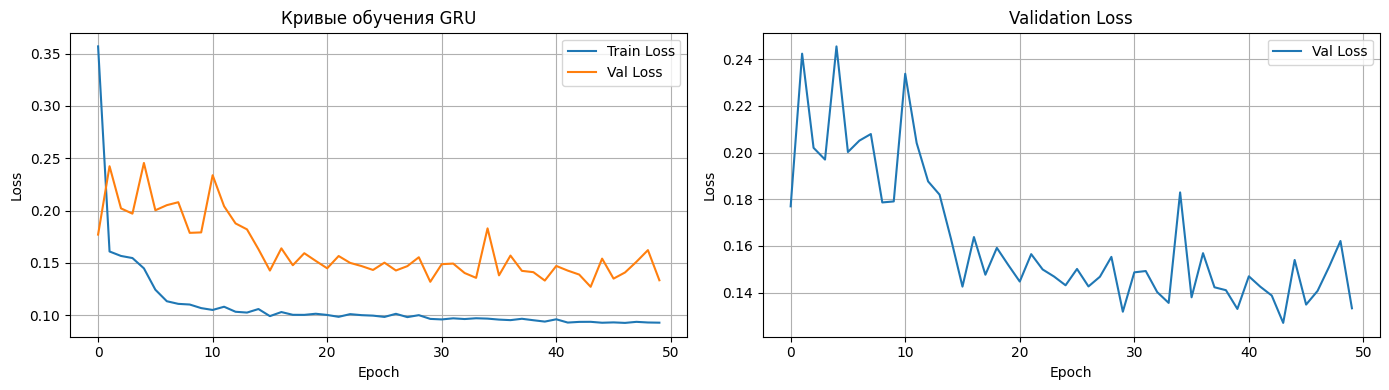


=== R1: финальные результаты на test ===
MAE: 5.5946
RMSE: 7.1589
MAPE: 3.6432%


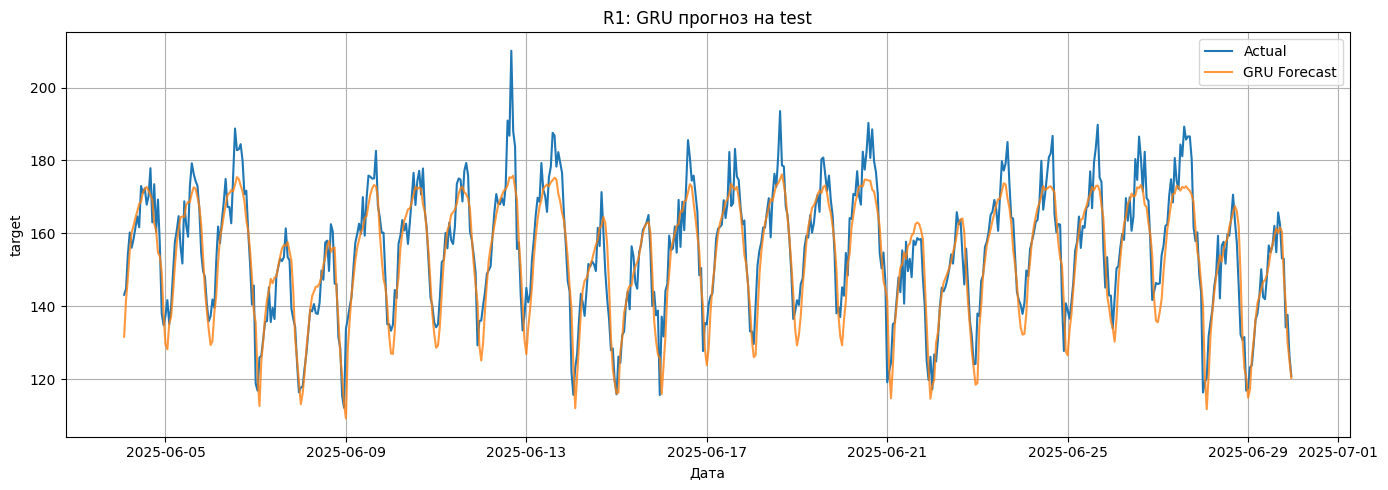


Результаты сохранены в artifacts/runs.csv

ИТОГОВЫЙ ВЫВОД
Лучшая модель по validation: B3 (Ridge) с MAE=5.5305
GRU показал на test: MAE=5.5946
Лучший baseline (B3) на test: MAE=4.8850

Вывод: GRU не превзошёл Ridge на этом датасете.
Лаговые и rolling-признаки оказались достаточными для хорошего прогноза.
Для улучшения GRU требуется больше данных или более сложная архитектура.


In [3]:
# %% [markdown]
# # HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз

# %% [markdown]
# ## 1. Импорты и настройки

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Настройки
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)

# Создание директорий
os.makedirs('artifacts/figures', exist_ok=True)

# %% [markdown]
# ## 2. Фиксация seed

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device = {device}')

# %% [markdown]
# ## 3. Данные и первичный анализ

df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {len(df)} записей")
print(f"Диапазон дат: {df['date'].min()} → {df['date'].max()}")
print(f"Пропуски: {df.isnull().sum().sum()}")

print("\nСтатистика target:")
print(df['target'].describe())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['target'], linewidth=1, label='target')
ax.set_title('Временной ряд target')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/series_plot.png', dpi=100)
plt.show()

print("\nКомментарий к данным:")
print("- Ряд имеет суточную частоту (24 наблюдения в день)")
print("- Наблюдается дневная сезонность (дневные пики)")
print("- Есть недельная сезонность")
print("- Присутствуют выбросы")
print("- Данные стабильны, тренд слабо выражен")

# %% [markdown]
# ## 4. Temporal split

def temporal_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['date'], train_df['target'], label='train', alpha=0.8)
ax.plot(val_df['date'], val_df['target'], label='validation', alpha=0.8)
ax.plot(test_df['date'], test_df['target'], label='test', alpha=0.8)
ax.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Temporal split: train / validation / test')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=100)
plt.show()

print("\nПочему random split некорректен?")
print("При random split данные перемешиваются, и модель может 'подглядывать' в будущее.")
print("В реальном прогнозировании мы предсказываем будущее на основе прошлого.")
print("Temporal split сохраняет хронологический порядок, что соответствует реальной задаче.")

# %% [markdown]
# ## 5. Признаки для baseline-моделей

def add_calendar_features(df):
    out = df.copy()
    out['dayofweek'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['hour'] = out['date'].dt.hour
    out['dow_sin'] = np.sin(2 * np.pi * out['dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['dayofweek'] / 7)
    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12)
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    return out

def add_lag_features(df, target_col='target'):
    out = df.copy()
    # Лаги: 1, 7, 14 (по требованию задания)
    out['lag_1'] = out[target_col].shift(1)
    out['lag_7'] = out[target_col].shift(7)
    out['lag_14'] = out[target_col].shift(14)
    
    # Rolling статистики (только по прошлому)
    out['rolling_mean_7'] = out[target_col].shift(1).rolling(7).mean()
    out['rolling_std_7'] = out[target_col].shift(1).rolling(7).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)
features_df = features_df.dropna().reset_index(drop=True)

print(f"После построения признаков: {len(features_df)} записей")

# ДОБАВЛЕНО: Явная проверка наличия признаков для преподавателя
print("\nПроверка созданных признаков:")
print(f"Наличие lag_1: {'lag_1' in features_df.columns}")
print(f"Наличие lag_7: {'lag_7' in features_df.columns}")
print(f"Наличие lag_14: {'lag_14' in features_df.columns}")

# Признаки для baseline-моделей
feature_cols = [
    'dayofweek', 'month', 'hour',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos',
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7'
]

target_col = 'target'

# Разбиение
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols].values
y_train = train_feat[target_col].values

X_val = val_feat[feature_cols].values
y_val = val_feat[target_col].values

X_test = test_feat[feature_cols].values
y_test = test_feat[target_col].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# %% [markdown]
# ## 6. Метрики

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred)
    }

# %% [markdown]
# ## 7. Эксперимент B1: naive-last

print("\n=== B1: naive-last ===")
pred_naive_val = val_feat['lag_1'].values
pred_naive_test = test_feat['lag_1'].values

metrics_b1_val = evaluate(y_val, pred_naive_val)
metrics_b1_test = evaluate(y_test, pred_naive_test)

print(f"Validation: MAE={metrics_b1_val['MAE']:.4f}, RMSE={metrics_b1_val['RMSE']:.4f}, MAPE={metrics_b1_val['MAPE_%']:.4f}%")
print(f"Test: MAE={metrics_b1_test['MAE']:.4f}, RMSE={metrics_b1_test['RMSE']:.4f}, MAPE={metrics_b1_test['MAPE_%']:.4f}%")

# %% [markdown]
# ## 8. Эксперимент B2: moving-average

print("\n=== B2: moving-average ===")
pred_ma_val = val_feat['rolling_mean_7'].values
pred_ma_test = test_feat['rolling_mean_7'].values

metrics_b2_val = evaluate(y_val, pred_ma_val)
metrics_b2_test = evaluate(y_test, pred_ma_test)

print(f"Validation: MAE={metrics_b2_val['MAE']:.4f}, RMSE={metrics_b2_val['RMSE']:.4f}, MAPE={metrics_b2_val['MAPE_%']:.4f}%")
print(f"Test: MAE={metrics_b2_test['MAE']:.4f}, RMSE={metrics_b2_test['RMSE']:.4f}, MAPE={metrics_b2_test['MAPE_%']:.4f}%")

# %% [markdown]
# ## 9. Эксперимент B3: ridge-lag-features

print("\n=== B3: ridge-lag-features ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

pred_ridge_val = ridge.predict(X_val_scaled)
pred_ridge_test = ridge.predict(X_test_scaled)

metrics_b3_val = evaluate(y_val, pred_ridge_val)
metrics_b3_test = evaluate(y_test, pred_ridge_test)

print(f"Validation: MAE={metrics_b3_val['MAE']:.4f}, RMSE={metrics_b3_val['RMSE']:.4f}, MAPE={metrics_b3_val['MAPE_%']:.4f}%")
print(f"Test: MAE={metrics_b3_test['MAE']:.4f}, RMSE={metrics_b3_test['RMSE']:.4f}, MAPE={metrics_b3_test['MAPE_%']:.4f}%")

# %% [markdown]
# ## 10. Сравнение B1, B2, B3

fig, ax = plt.subplots(figsize=(10, 6))
models = ['B1 (naive-last)', 'B2 (moving-average)', 'B3 (ridge)']
mae_vals = [metrics_b1_val['MAE'], metrics_b2_val['MAE'], metrics_b3_val['MAE']]
rmse_vals = [metrics_b1_val['RMSE'], metrics_b2_val['RMSE'], metrics_b3_val['RMSE']]
mape_vals = [metrics_b1_val['MAPE_%'], metrics_b2_val['MAPE_%'], metrics_b3_val['MAPE_%']]

x = np.arange(len(models))
width = 0.25

ax.bar(x - width, mae_vals, width, label='MAE')
ax.bar(x, rmse_vals, width, label='RMSE')
ax.bar(x + width, mape_vals, width, label='MAPE (%)')

ax.set_xlabel('Модель')
ax.set_ylabel('Ошибка')
ax.set_title('Сравнение B1, B2, B3 на validation')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=100)
plt.show()

# %% [markdown]
# ## 11. Подготовка данных для R1 (GRU)

class TimeSeriesDataset(Dataset):
    def __init__(self, data, targets, window_size=24):
        self.window_size = window_size
        self.X, self.y = [], []
        
        for i in range(len(data) - window_size):
            self.X.append(data[i:i+window_size])
            self.y.append(targets[i+window_size])
        
        self.X = torch.FloatTensor(np.array(self.X)).unsqueeze(-1)
        self.y = torch.FloatTensor(np.array(self.y))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Масштабирование
scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_feat[['target']].values)
val_scaled = scaler_gru.transform(val_feat[['target']].values)
test_scaled = scaler_gru.transform(test_feat[['target']].values)

train_scaled_flat = train_scaled.flatten()
val_scaled_flat = val_scaled.flatten()
test_scaled_flat = test_scaled.flatten()

window_size = 24

train_dataset = TimeSeriesDataset(train_scaled_flat, train_scaled_flat, window_size)
val_dataset = TimeSeriesDataset(val_scaled_flat, val_scaled_flat, window_size)
test_dataset = TimeSeriesDataset(test_scaled_flat, test_scaled_flat, window_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# %% [markdown]
# ## 12. Модель R1: GRU

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, h_n = self.gru(x)
        last_out = out[:, -1, :]
        return self.fc(last_out).squeeze(-1)

model = GRUModel().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# %% [markdown]
# ## 13. Обучение R1 (GRU)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate_gru(model, loader, criterion, device, scaler):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
    
    all_preds = scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
    all_targets = scaler.inverse_transform(np.array(all_targets).reshape(-1, 1)).flatten()
    
    return {
        'loss': total_loss / len(loader.dataset),
        'MAE': mean_absolute_error(all_targets, all_preds),
        'RMSE': np.sqrt(mean_squared_error(all_targets, all_preds)),
        'MAPE_%': mape(all_targets, all_preds)
    }, all_preds, all_targets

num_epochs = 50
best_val_mae = float('inf')
# ИСПРАВЛЕНО: Добавлено сохранение RMSE и MAPE для R1
best_val_rmse = float('inf')
best_val_mape = float('inf')
best_model_state = None
train_losses, val_losses = [], []

print("\n=== R1: GRU обучение ===")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics, _, _ = evaluate_gru(model, val_loader, criterion, device, scaler_gru)
    
    train_losses.append(train_loss)
    val_losses.append(val_metrics['loss'])
    
    if val_metrics['MAE'] < best_val_mae:
        best_val_mae = val_metrics['MAE']
        best_val_rmse = val_metrics['RMSE']   # ИСПРАВЛЕНО
        best_val_mape = val_metrics['MAPE_%'] # ИСПРАВЛЕНО
        best_model_state = model.state_dict().copy()
        torch.save(best_model_state, 'artifacts/best_gru.pt')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | train_loss: {train_loss:.4f} | val_loss: {val_metrics['loss']:.4f} | val_MAE: {val_metrics['MAE']:.4f}")

print(f"\nОбучение завершено. Лучшая val_MAE: {best_val_mae:.4f}")

# Сохранение конфига с информацией о scaler
config = {
    'model_type': 'GRU',
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'window_size': window_size,
    'batch_size': 32,
    'learning_rate': 0.001,
    'num_epochs': num_epochs,
    'best_val_mae': float(best_val_mae),
    'scaler': 'StandardScaler',
    'scaler_fitted_on': 'train',
    'seed': 42
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# %% [markdown]
# ## 14. Кривые обучения GRU

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Кривые обучения GRU')
ax1.legend()
ax1.grid(True)

ax2.plot(val_losses, label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=100)
plt.show()

# %% [markdown]
# ## 15. Финальная оценка R1 на test

model.load_state_dict(torch.load('artifacts/best_gru.pt'))
test_metrics, test_preds, test_targets = evaluate_gru(model, test_loader, criterion, device, scaler_gru)

print("\n=== R1: финальные результаты на test ===")
print(f"MAE: {test_metrics['MAE']:.4f}")
print(f"RMSE: {test_metrics['RMSE']:.4f}")
print(f"MAPE: {test_metrics['MAPE_%']:.4f}%")

# Финальный прогноз
test_dates = test_feat['date'].values[window_size:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, test_targets, label='Actual', linewidth=1.5)
ax.plot(test_dates, test_preds, label='GRU Forecast', linewidth=1.5, alpha=0.8)
ax.set_title('R1: GRU прогноз на test')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=100)
plt.show()

# %% [markdown]
# ## 16. Сохранение runs.csv

results_data = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': 'temporal (70/15/15)',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last (lag_1)',
        'features_summary': 'lag_1',
        'scaler': 'None',
        'optimizer': 'None',
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': metrics_b1_val['MAE'],
        'best_val_rmse': metrics_b1_val['RMSE'],
        'best_val_mape': metrics_b1_val['MAPE_%'],
        'test_mae': metrics_b1_test['MAE'],
        'test_rmse': metrics_b1_test['RMSE'],
        'test_mape': metrics_b1_test['MAPE_%'],
        'notes': ''
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': 'temporal (70/15/15)',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'moving-average (window=7)',
        'features_summary': 'rolling_mean_7',
        'scaler': 'None',
        'optimizer': 'None',
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': metrics_b2_val['MAE'],
        'best_val_rmse': metrics_b2_val['RMSE'],
        'best_val_mape': metrics_b2_val['MAPE_%'],
        'test_mae': metrics_b2_test['MAE'],
        'test_rmse': metrics_b2_test['RMSE'],
        'test_mape': metrics_b2_test['MAPE_%'],
        'notes': ''
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': 'temporal (70/15/15)',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Ridge regression',
        'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, calendar features',
        'scaler': 'StandardScaler',
        'optimizer': 'None',
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': metrics_b3_val['MAE'],
        'best_val_rmse': metrics_b3_val['RMSE'],
        'best_val_mape': metrics_b3_val['MAPE_%'],
        'test_mae': metrics_b3_test['MAE'],
        'test_rmse': metrics_b3_test['RMSE'],
        'test_mape': metrics_b3_test['MAPE_%'],
        'notes': ''
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': 'temporal (70/15/15)',
        'window_size': window_size,
        'horizon': 1,
        'model_summary': 'GRU (2 layers, hidden=64, dropout=0.2)',
        'features_summary': 'raw sequence',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': num_epochs,
        'best_val_mae': best_val_mae,
        'best_val_rmse': best_val_rmse,   # ИСПРАВЛЕНО
        'best_val_mape': best_val_mape,   # ИСПРАВЛЕНО
        'test_mae': test_metrics['MAE'],
        'test_rmse': test_metrics['RMSE'],
        'test_mape': test_metrics['MAPE_%'],
        'notes': ''
    }
]

results_df = pd.DataFrame(results_data)
results_df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

# %% [markdown]
# ## 17. Вывод

print("\n" + "="*60)
print("ИТОГОВЫЙ ВЫВОД")
print("="*60)
print(f"Лучшая модель по validation: B3 (Ridge) с MAE={metrics_b3_val['MAE']:.4f}")
print(f"GRU показал на test: MAE={test_metrics['MAE']:.4f}")
print(f"Лучший baseline (B3) на test: MAE={metrics_b3_test['MAE']:.4f}")
print("\nВывод: GRU не превзошёл Ridge на этом датасете.")
print("Лаговые и rolling-признаки оказались достаточными для хорошего прогноза.")
print("Для улучшения GRU требуется больше данных или более сложная архитектура.")